In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew

In [2]:
df = pd.read_excel('../data/raw/second_task.xlsx')
df.head()

,HR rest,SBP rest,DBP rest,WMSI rest,LAD at rest,B-lines at rest,GLS rest,HR stress,HRR,HRR range,...,GLS delta,B range,D WMSI,WMSI range,LV CR range,СFVR range,ABCDE score,ABCDE score+ECG,ABCDE score+ECG+angina,FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)
0,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,0.0,NaN,NaN,0.0,0.0,0.0,1.0
1,81.0,106.0,68.0,1.125,19.0,NaN,NaN,98.0,1.209877,1.0,...,NaN,NaN,0.000,0.0,NaN,0.0,1.0,1.0,1.0,1.0
2,62.0,131.0,66.0,1.000,22.0,NaN,NaN,90.0,1.451613,0.0,...,NaN,NaN,0.125,1.0,NaN,0.0,1.0,1.0,1.0,0.0
3,70.0,173.0,94.0,1.190,37.0,NaN,NaN,90.0,1.285714,0.0,...,NaN,NaN,-0.190,1.0,1.0,1.0,3.0,4.0,4.0,1.0
4,52.0,98.0,80.0,1.000,24.0,0.0,18.3,77.0,1.480769,0.0,...,3.4,0.0,0.120,1.0,0.0,0.0,1.0,1.0,1.0,0.0


In [3]:
df.columns

Index(['HR rest', 'SBP rest', 'DBP rest', 'WMSI  rest', 'LAD at rest',
       'B-lines at rest', 'GLS rest', 'HR stress', 'HRR', 'HRR range',
       'WMSI stress', 'LAD stress', 'B-lines stress', 'GLS stress-',
       'GLS reserve', 'GLS delta', 'B range', 'D WMSI', 'WMSI range',
       'LV CR range', 'СFVR range', 'ABCDE score', 'ABCDE score+ECG',
       'ABCDE score+ECG+angina',
       'FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)'],
      dtype='object')

In [4]:
df.shape

(537, 25)

In [5]:
df = df[['WMSI range', 'B range', 'LV CR range', 'СFVR range', 'HRR range', 'GLS stress-',
       'GLS reserve', 'GLS delta', 'ABCDE score', 'ABCDE score+ECG',
       'ABCDE score+ECG+angina', 'FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)']]
df.head()

,WMSI range,B range,LV CR range,СFVR range,HRR range,GLS stress-,GLS reserve,GLS delta,ABCDE score,ABCDE score+ECG,ABCDE score+ECG+angina,FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
1,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0
2,1.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1.0,1.0,1.0,0.0
3,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,3.0,4.0,4.0,1.0
4,1.0,0.0,0.0,0.0,0.0,21.7,1.185792,3.4,1.0,1.0,1.0,0.0


In [6]:
df = df.rename(columns={'FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)': 'target', 'СFVR range': 'CFVR range', 'ABCDE score+ECG+angina': 'ASEA', 'ABCDE score+ECG':'ASE', 'ABCDE score':'AS'})
df.head()

,WMSI range,B range,LV CR range,CFVR range,HRR range,GLS stress-,GLS reserve,GLS delta,AS,ASE,ASEA,target
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
1,0.0,NaN,NaN,0.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0
2,1.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1.0,1.0,1.0,0.0
3,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,3.0,4.0,4.0,1.0
4,1.0,0.0,0.0,0.0,0.0,21.7,1.185792,3.4,1.0,1.0,1.0,0.0


In [7]:
df.isna().sum()

WMSI range      21
B range         42
LV CR range     26
CFVR range     218
HRR range       22
GLS stress-    146
GLS reserve    149
GLS delta      149
AS              21
ASE             21
ASEA            21
target          35
dtype: int64

In [8]:
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
unique_rows = df.drop_duplicates().shape[0]

print(f"Всего строк: {total_rows}")
print(f"Уникальных строк: {unique_rows}")
print(f"Дублирующихся строк: {duplicate_rows}")
print(f"Процент дубликатов: {duplicate_rows/total_rows*100:.2f}%")

Всего строк: 537
Уникальных строк: 482
Дублирующихся строк: 55
Процент дубликатов: 10.24%


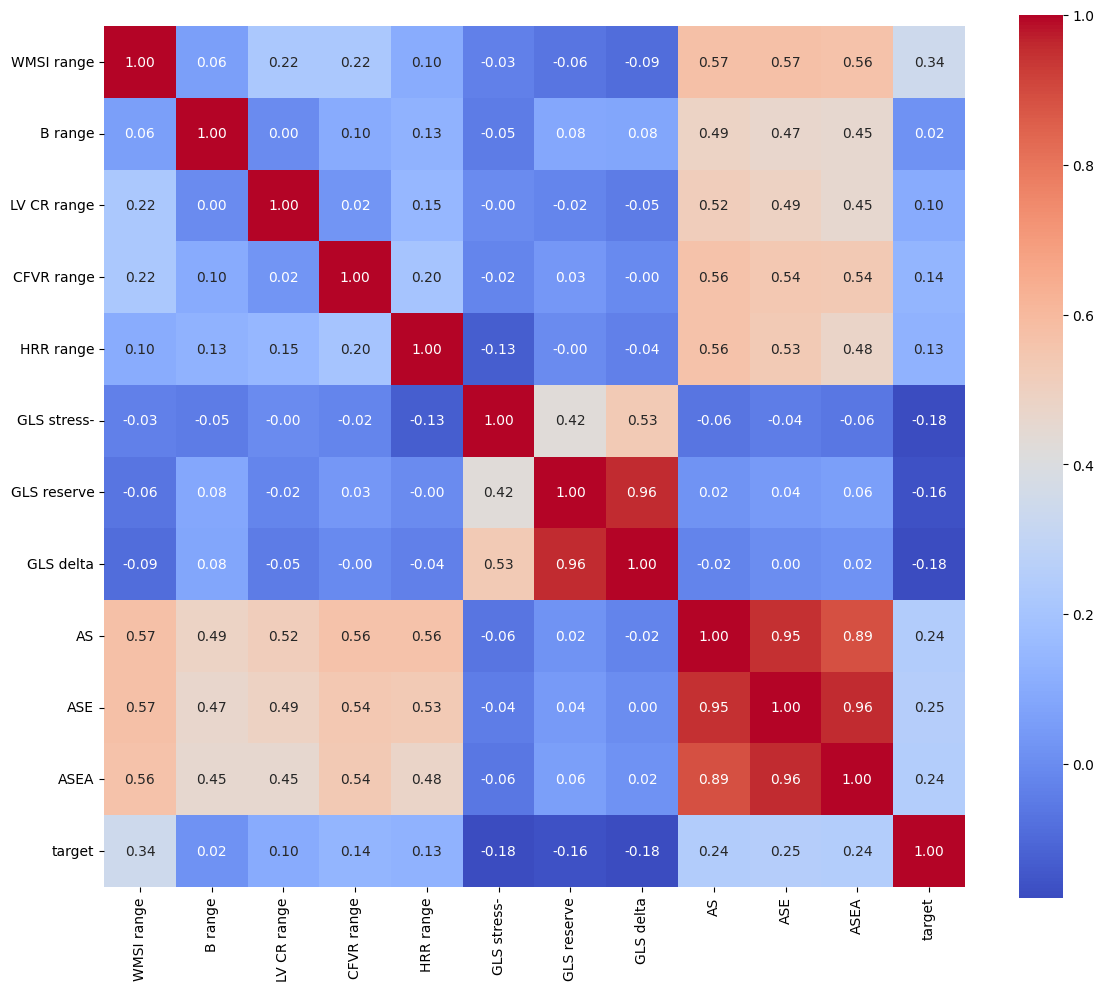

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))  

sns.heatmap(df.corr(), cmap='coolwarm', annot=True, 
            fmt='.2f',  
            square=True,  
            annot_kws={'size': 10}) 
plt.tight_layout()
plt.show()

In [10]:
df['target'].value_counts()

target
0.0    369
1.0    133
Name: count, dtype: int64

In [11]:
df['target'].value_counts(normalize=True)

target
0.0    0.73506
1.0    0.26494
Name: proportion, dtype: float64

In [12]:
df['B range'].value_counts()

B range
0.0    267
1.0    228
Name: count, dtype: int64

In [13]:
df['LV CR range'].value_counts()

LV CR range
1.0    310
0.0    201
Name: count, dtype: int64

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Count'>

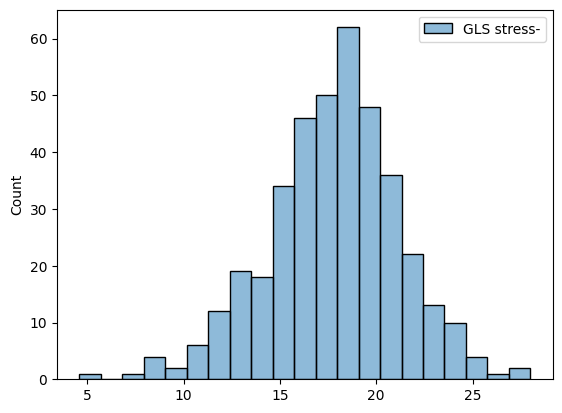

In [14]:
sns.histplot(df[['GLS stress-']])

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Count'>

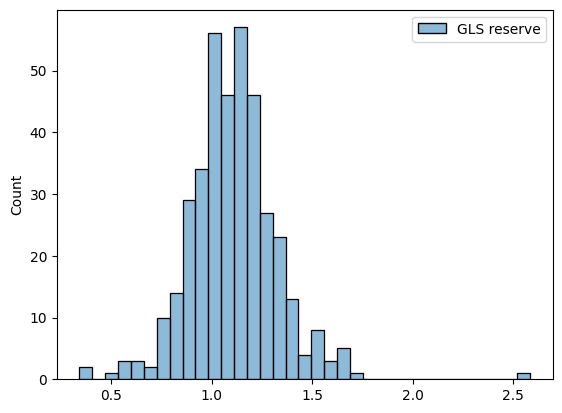

In [15]:
sns.histplot(df[['GLS reserve']])

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Count'>

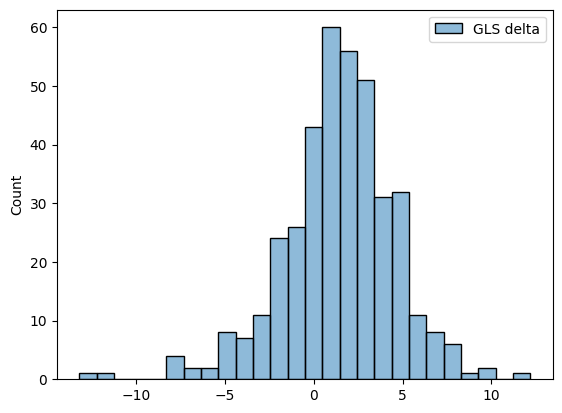

In [16]:
sns.histplot(df[['GLS delta']])

In [17]:
from scipy.stats import chi2_contingency

x = ['WMSI range', 'B range', 'LV CR range', 'CFVR range', 'HRR range']
for features in x:
    contingency = pd.crosstab(df[features], df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square p-value (target vs. {features}): {p:.4f}")

Chi-square p-value (target vs. WMSI range): 0.0000
Chi-square p-value (target vs. B range): 0.7532
Chi-square p-value (target vs. LV CR range): 0.0343
Chi-square p-value (target vs. CFVR range): 0.0220
Chi-square p-value (target vs. HRR range): 0.0054


In [18]:
for col in df.columns:
    if col in x:
        print(f"\n{'='*50}")
        print(f"=== {col} vs target ===")
        print('='*50)
        
        cross = pd.crosstab(df[col], df['target'], normalize='index')
        print(cross)
        print()


=== WMSI range vs target ===
target           0.0       1.0
WMSI range                    
0.0         0.843373  0.156627
1.0         0.523529  0.476471


=== B range vs target ===
target        0.0       1.0
B range                    
0.0      0.751908  0.248092
1.0      0.735160  0.264840


=== LV CR range vs target ===
target            0.0       1.0
LV CR range                    
0.0          0.790816  0.209184
1.0          0.700997  0.299003


=== CFVR range vs target ===
target          0.0      1.0
CFVR range                  
0.0         0.79085  0.20915
1.0         0.66879  0.33121


=== HRR range vs target ===
target          0.0       1.0
HRR range                    
0.0        0.785965  0.214035
1.0        0.671296  0.328704



c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='target', ylabel='GLS stress-'>

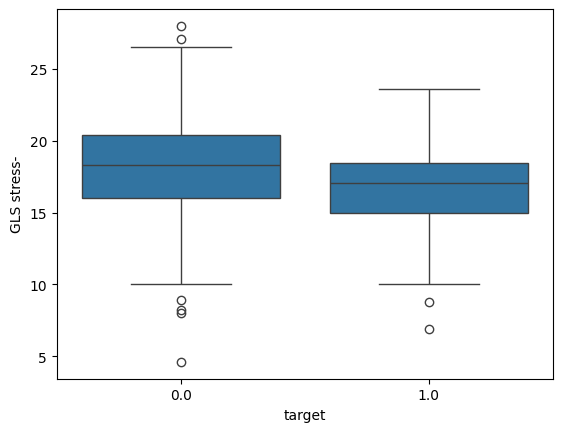

In [19]:
sns.boxplot(x='target', y='GLS stress-', data=df)

Если GLS stress- больше своей медианы, значит, скорее всего, прогноз хуже

In [20]:
m = df.loc[(df['target'] == 0), 'GLS stress-'].median()
# print(m)

df.loc[df['target'] == 0, ['GLS stress-', 'target']].max()


GLS stress-    28.0
target          0.0
dtype: float64

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='target', ylabel='GLS reserve'>

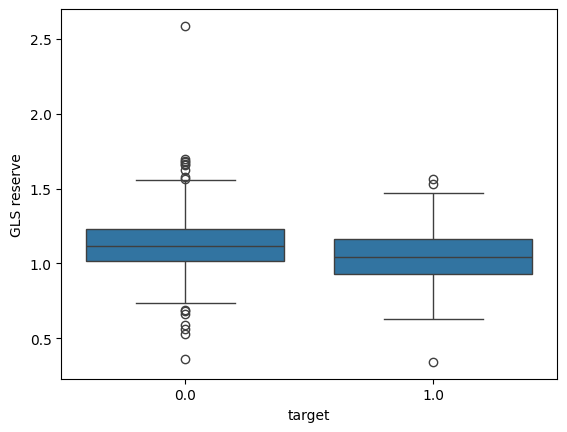

In [21]:
sns.boxplot(x='target', y='GLS reserve', data=df)

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='target', ylabel='GLS delta'>

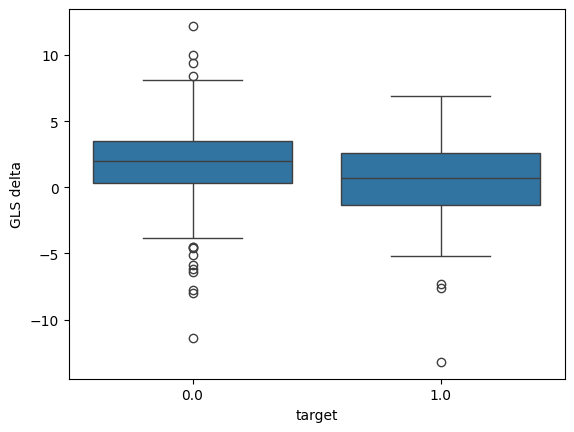

In [22]:
sns.boxplot(x='target', y='GLS delta', data=df)

In [23]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

def quick_feature_analysis(df, target_col):
    
    print(f"{'Признак':<25} {'Тип':<12} {'Тест':<15} {'p-value':<12} {'Значимо'}")
    print("-" * 80)
    
    for col in df.columns:
        if col == target_col:
            continue
        
        if df[col].nunique() < 10:
            contingency = pd.crosstab(df[col], df[target_col])
            
            if contingency.shape[0] == 2 and contingency.shape[1] == 2:
                _, p = fisher_exact(contingency)
                test_name = "Fisher"
            else:
                _, p, _, _ = chi2_contingency(contingency)
                test_name = "Chi-square"
            
            feat_type = "категориальный"
            
        else:
            g0 = df[df[target_col]==0][col].dropna()
            g1 = df[df[target_col]==1][col].dropna()
            _, p = mannwhitneyu(g0, g1, alternative='two-sided')
            test_name = "Mann-Whitney"
            feat_type = "непрерывный"
        
        significant = "✅" if p < 0.05 else "❌"
        print(f"{col:<25} {feat_type:<12} {test_name:<15} {p:.6f}    {significant}")

quick_feature_analysis(df, 'target')

Признак                   Тип          Тест            p-value      Значимо
--------------------------------------------------------------------------------
WMSI range                категориальный Fisher          0.000000    ✅
B range                   категориальный Fisher          0.676333    ❌
LV CR range               категориальный Fisher          0.028792    ✅
CFVR range                категориальный Fisher          0.021123    ✅
HRR range                 категориальный Fisher          0.004213    ✅
GLS stress-               непрерывный  Mann-Whitney    0.000276    ✅
GLS reserve               непрерывный  Mann-Whitney    0.001240    ✅
GLS delta                 непрерывный  Mann-Whitney    0.000900    ✅
AS                        категориальный Chi-square      0.000000    ✅
ASE                       категориальный Chi-square      0.000003    ✅
ASEA                      категориальный Chi-square      0.000001    ✅


По таким результатам можно сделать вывод, что только признак B range не имеет статистической значимой связи между им и таргетом

In [24]:
from sklearn.metrics import roc_auc_score
df_without_nan = df.dropna()
auc = roc_auc_score(df_without_nan['target'], df_without_nan['GLS stress-'])
print(f"AUC для GLS stress: {auc:.3f}")

auc = roc_auc_score(df_without_nan['target'], df_without_nan['GLS delta'])
print(f"AUC для GLS delta: {auc:.3f}")

auc = roc_auc_score(df_without_nan['target'], df_without_nan['GLS reserve'])
print(f"AUC для GLS reserve: {auc:.3f}")

AUC для GLS stress: 0.370
AUC для GLS delta: 0.406
AUC для GLS reserve: 0.410


In [25]:
df.columns

Index(['WMSI range', 'B range', 'LV CR range', 'CFVR range', 'HRR range',
       'GLS stress-', 'GLS reserve', 'GLS delta', 'AS', 'ASE', 'ASEA',
       'target'],
      dtype='object')

In [26]:
df.isna().sum()

WMSI range      21
B range         42
LV CR range     26
CFVR range     218
HRR range       22
GLS stress-    146
GLS reserve    149
GLS delta      149
AS              21
ASE             21
ASEA            21
target          35
dtype: int64

In [27]:
df = pd.read_excel('../data/raw/second_task.xlsx')
df = df[['WMSI range', 'B range', 'LV CR range', 'СFVR range', 'HRR range', 'GLS stress-',
       'GLS reserve', 'GLS delta', 'ABCDE score', 'ABCDE score+ECG',
       'ABCDE score+ECG+angina', 'FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)']]
df = df.rename(columns={'FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)': 'target', 'СFVR range': 'CFVR range', 'ABCDE score+ECG+angina': 'ASEA', 'ABCDE score+ECG':'ASE', 'ABCDE score':'AS'})


In [28]:
from sklearn.impute import KNNImputer

def knn_imputation(df, feature_name, k=3):
    imputer = KNNImputer(n_neighbors=k)
    df_imputed = pd.DataFrame(imputer.fit_transform(df), 
                              columns=df.columns)
    return df_imputed[feature_name]

cols_to_imput = ['GLS stress-', 'GLS reserve', 'GLS delta']

for col in cols_to_imput:
    df[col] = knn_imputation(df, col)
print(df.isna().sum())
df.head()

WMSI range      21
B range         42
LV CR range     26
CFVR range     218
HRR range       22
GLS stress-      0
GLS reserve      0
GLS delta        0
AS              21
ASE             21
ASEA            21
target          35
dtype: int64


,WMSI range,B range,LV CR range,CFVR range,HRR range,GLS stress-,GLS reserve,GLS delta,AS,ASE,ASEA,target
0,0.0,NaN,NaN,NaN,NaN,18.000000,1.014724,0.100000,0.0,0.0,0.0,1.0
1,0.0,NaN,NaN,0.0,1.0,11.533333,0.837519,-2.333333,1.0,1.0,1.0,1.0
2,1.0,NaN,NaN,0.0,0.0,20.933333,1.116325,2.133333,1.0,1.0,1.0,0.0
3,1.0,NaN,1.0,1.0,0.0,15.700000,0.971193,-0.466667,3.0,4.0,4.0,1.0
4,1.0,0.0,0.0,0.0,0.0,21.700000,1.185792,3.400000,1.0,1.0,1.0,0.0


In [29]:
df['CFVR_nan'] = np.where(df['CFVR range'].isna(), 1, 0)
df['CFVR range'] = np.where(df['CFVR range'].isna(), 2, df['CFVR range'])

In [30]:
prob_1 = df['B range'].mean()  
prob_0 = 1 - prob_1

mask = df['B range'].isna()
n_missing = mask.sum()
random_values = np.random.choice([0, 1], size=n_missing, p=[prob_0, prob_1])
df.loc[mask, 'B range'] = random_values

In [31]:
df['WMSI range'] = df['WMSI range'].fillna(df['WMSI range'].mode()[0])
df['LV CR range'] = df['LV CR range'].fillna(df['LV CR range'].mode()[0])
df['HRR range'] = df['HRR range'].fillna(df['HRR range'].mode()[0])

In [32]:
df.isna().sum()

WMSI range      0
B range         0
LV CR range     0
CFVR range      0
HRR range       0
GLS stress-     0
GLS reserve     0
GLS delta       0
AS             21
ASE            21
ASEA           21
target         35
CFVR_nan        0
dtype: int64

In [33]:
y_for_test = df.loc[df['target'].isna()]
no_y_idx = y_for_test.index
df_for_train = df.drop(index=no_y_idx)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score,  confusion_matrix, recall_score, roc_auc_score, make_scorer,precision_score, f1_score
from sklearn.pipeline import Pipeline

features = ['WMSI range', 
            # 'B range', 
            # 'LV CR range', 
            # 'CFVR range', 
            'HRR range', 
            # 'GLS stress-', 
            # 'GLS reserve', 
            'GLS delta', 
            # 'CFVR_nan'
            ]

# features = ['WMSI range', 'GLS stress-', 'GLS reserve', 'GLS delta', 'HRR range']  # best 


X_small = df_for_train[features].copy()
y_work = df_for_train['target'].copy()

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    # shuffle=True,
    random_state=42
)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

specificity_scorer = make_scorer(specificity_score)

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": specificity_scorer, 
    'auc-roc' : make_scorer(roc_auc_score, needs_proba=True)
}

cv_results = cross_validate(
    model_log,
    X_small,
    y_work,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],
    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],
    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],
    "Specificity mean": [cv_results["test_specificity"].mean()],  
    "Specificity std": [cv_results["test_specificity"].std()],   
    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],
    "ROC-AUC mean": [cv_results["test_auc-roc"].mean()],
    "ROC-AUC std": [cv_results["test_auc-roc"].std()],
})

model_log.fit(X_small, y_work)

coef = model_log.named_steps["clf"].coef_.ravel()

coef_df = (
    pd.Series(coef, index=features)
    .sort_values(key=np.abs, ascending=False)
)

print(coef_df)
metrics_df

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


WMSI range    0.723288
GLS delta    -0.477582
HRR range     0.209525
dtype: float64


,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,ROC-AUC mean,ROC-AUC std
0,0.541142,0.061371,0.46785,0.057753,0.646752,0.085638,0.731951,0.050852,0.709378,0.044186,0.74811,0.048511


In [35]:
from sklearn.model_selection import GridSearchCV, cross_val_predict

features = [
    'WMSI range',
    'B range',
    'LV CR range',
    'CFVR range',
    'HRR range',
    # 'GLS stress-',
    # 'GLS reserve',
    'GLS delta',
    'CFVR_nan'
]

X_small = df_for_train[features].copy()
y_work = df_for_train['target'].copy()

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        random_state=10,
        max_iter=5000
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

param_grid = {
    'clf__C': np.logspace(-3, 2, 30)
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_small, y_work)

print('=' * 50)
print('BEST PARAMS:')
print(grid.best_params_)

print('\nBEST ROC-AUC:')
print(grid.best_score_)

best_model = grid.best_estimator_

coef = best_model.named_steps['clf'].coef_.ravel()

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef
})

coef_df['Abs'] = np.abs(coef_df['Coefficient'])

coef_df = coef_df.sort_values(
    by='Abs',
    ascending=False
)

print('\nALL COEFFICIENTS:')
print(coef_df[['Feature', 'Coefficient']])

selected_features = coef_df[
    coef_df['Coefficient'] != 0
]['Feature'].tolist()

print('\nSELECTED FEATURES:')
print(selected_features)

dropped_features = coef_df[
    coef_df['Coefficient'] == 0
]['Feature'].tolist()

print('\nDROPPED FEATURES:')
print(dropped_features)

BEST PARAMS:
{'clf__C': np.float64(0.07880462815669913)}

BEST ROC-AUC:
0.7454019773197855

ALL COEFFICIENTS:
       Feature  Coefficient
0   WMSI range     0.608759
5    GLS delta    -0.340453
4    HRR range     0.098439
2  LV CR range     0.000000
1      B range     0.000000
3   CFVR range     0.000000
6     CFVR_nan     0.000000

SELECTED FEATURES:
['WMSI range', 'GLS delta', 'HRR range']

DROPPED FEATURES:
['LV CR range', 'B range', 'CFVR range', 'CFVR_nan']


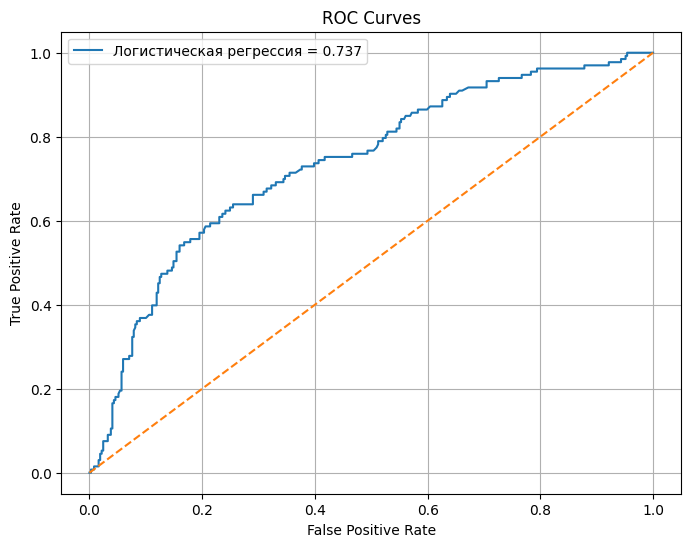

In [36]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_curve

cv = StratifiedKFold(
    n_splits=5,
    shuffle = True,
    random_state=42
)

y_proba_log = cross_val_predict(
    best_model,
    df_for_train[['WMSI range', 'HRR range', 'GLS delta']],
    y_work,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_work, y_proba_log)
auc_log = roc_auc_score(y_work, y_proba_log)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Логистическая регрессия = {auc_log:.3f}'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

plt.legend()
plt.grid(True)

plt.show()

In [56]:
from catboost import CatBoostClassifier

features = [
    'WMSI range',
    # 'B range',
    # 'LV CR range',
    # 'CFVR range',
    'HRR range',
    # 'GLS stress-',
    # 'GLS reserve',
    'GLS delta',
    # 'CFVR_nan'
]

X_small = df_for_train[features].copy()
y_work = df_for_train['target'].copy()

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

specificity_scorer = make_scorer(specificity_score)

model_cat = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": specificity_scorer,
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    model_cat,
    X_small,
    y_work,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],

    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],

    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],

    "Specificity mean": [cv_results["test_specificity"].mean()],
    "Specificity std": [cv_results["test_specificity"].std()],

    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],

    "ROC-AUC mean": [cv_results["test_roc_auc"].mean()],
    "ROC-AUC std": [cv_results["test_roc_auc"].std()],
})

model_cat.fit(X_small, y_work)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": model_cat.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\nFeature importance:")
print(importance_df)
metrics_df


Feature importance:
      feature  importance
2   GLS delta   71.791306
0  WMSI range   20.139785
1   HRR range    8.068909


,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,ROC-AUC mean,ROC-AUC std
0,0.5097,0.062275,0.462147,0.055663,0.573419,0.08851,0.757664,0.047748,0.70895,0.038732,0.704299,0.060591


In [55]:
# gls, hrr, cfvr, wmsi
metrics_df

,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,ROC-AUC mean,ROC-AUC std
0,0.491204,0.059143,0.444256,0.05084,0.553875,0.087725,0.749548,0.041129,0.69779,0.033784,0.689997,0.054737


In [53]:
metrics_df

,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,ROC-AUC mean,ROC-AUC std
0,0.533714,0.062286,0.477679,0.05679,0.608718,0.085791,0.758797,0.039544,0.719107,0.037616,0.708648,0.047504


In [42]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from tqdm import tqdm

features = [
    'WMSI range',
    # 'B range',
    # 'LV CR range',
    'CFVR range',
    'HRR range',
    'GLS stress-',
    # 'GLS reserve',
    # 'GLS delta',
    # 'CFVR_nan'
]

X_small = df_for_train[features].copy()
y_work = df_for_train['target'].copy()

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False, 
        'auto_class_weights': 'Balanced'
    }
    
    model = CatBoostClassifier(**params)
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=8)
    scores = cross_val_score(model, X_small, y_work, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(
    direction='maximize',  
    sampler=TPESampler(seed=42),
    study_name='catboost_optimization'
)

study.optimize(
    objective, 
    n_trials=50, 
    n_jobs=1,
)

print("ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"{key}: {value}")

print(f"\nЛучшее значение метрики: {study.best_value:.4f}")


final_params = best_params.copy()
final_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 0,
    'auto_class_weights': 'Balanced'
})

print("Параметры модели:")
for key, value in final_params.items():
    print(f"  {key}: {value}")

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_small, y_work)

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": make_scorer(specificity_score),
    "roc_auc": "roc_auc"
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=8)

cv_results = cross_validate(
    final_model,
    X_small,
    y_work,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

# Результаты
metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],
    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],
    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],
    "Specificity mean": [cv_results["test_specificity"].mean()],
    "Specificity std": [cv_results["test_specificity"].std()],
    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],
    "ROC-AUC mean": [cv_results["test_roc_auc"].mean()],
    "ROC-AUC std": [cv_results["test_roc_auc"].std()],
})

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ (CV):")
print("="*50)
print(metrics_df)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": final_model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

print("\n" + "="*50)
print("FEATURE IMPORTANCE:")
print("="*50)
print(importance_df)

ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:
iterations: 318
depth: 6
learning_rate: 0.010801217795354378
l2_leaf_reg: 8.826002831314407

Лучшее значение метрики: 0.7611
Параметры модели:
  iterations: 318
  depth: 6
  learning_rate: 0.010801217795354378
  l2_leaf_reg: 8.826002831314407
  loss_function: Logloss
  eval_metric: AUC
  random_seed: 42
  verbose: 0
  auto_class_weights: Balanced

РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ (CV):
    F1 mean   F1 std  Precision mean  Precision std  Recall mean  Recall std  \
0  0.576182  0.05969        0.534624       0.070271     0.633476    0.084165   

   Specificity mean  Specificity std  Accuracy mean  Accuracy std  \
0           0.79614         0.054796       0.753007      0.040916   

   ROC-AUC mean  ROC-AUC std  
0      0.762584     0.047295  

FEATURE IMPORTANCE:
       feature  importance
3  GLS stress-   36.437270
0   WMSI range   36.131171
1   CFVR range   15.659633
2    HRR range   11.771926


In [43]:
metrics_df

,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,ROC-AUC mean,ROC-AUC std
0,0.576182,0.05969,0.534624,0.070271,0.633476,0.084165,0.79614,0.054796,0.753007,0.040916,0.762584,0.047295


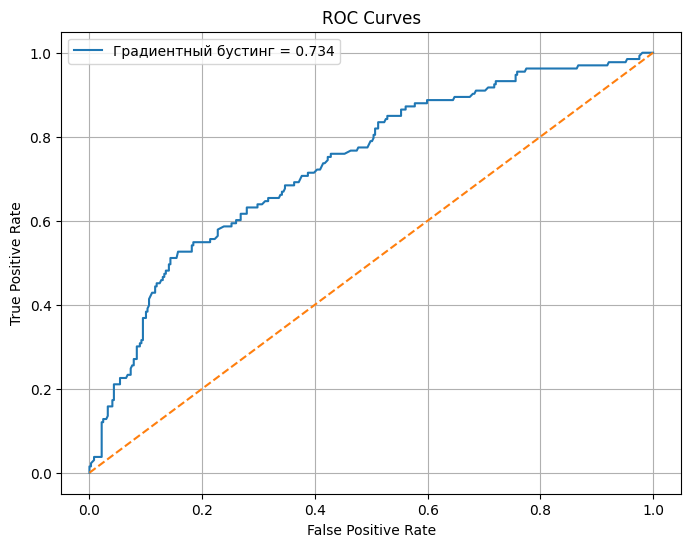

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle = True,
    random_state=10
)

y_proba_cat = cross_val_predict(
    final_model,
    df_for_train[['WMSI range', 'HRR range', 'GLS delta']],
    y_work,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_work, y_proba_cat)
auc_cat = roc_auc_score(y_work, y_proba_cat)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Градиентный бустинг = {auc_cat:.3f}'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from scipy import stats


def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r] = compute_midrank(positive_examples[r])
        ty[r] = compute_midrank(negative_examples[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n

    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    pvalue = 2 * (1 - stats.norm.cdf(z))
    return pvalue


def delong_roc_test(y_true, pred1, pred2):
    order = np.argsort(-y_true)

    y_true_sorted = y_true[order]

    preds = np.vstack((pred1, pred2))[:, order]

    label_1_count = int(np.sum(y_true))

    aucs, delongcov = fast_delong(preds, label_1_count)

    pvalue = calc_pvalue(aucs, delongcov)

    return aucs, pvalue[0][0]

aucs, p_value = delong_roc_test(
    y_work.values,
    y_proba_log,
    y_proba_cat
)

print(f"Логистическая регрессия AUC: {aucs[0]:.4f}")
print(f"Градиентный бустинг AUC: {aucs[1]:.4f}")
print(f"DeLong p-value: {p_value:.6f}")

Логистическая регрессия AUC: 0.6875
Градиентный бустинг AUC: 0.6903
DeLong p-value: 0.502268


In [ ]:
check = df[['AS', 'ASE', 'ASEA', 'target']]
check = check.dropna()
check.head()

,AS,ASE,ASEA,target
0,0.0,0.0,0.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,0.0
3,3.0,4.0,4.0,1.0
4,1.0,1.0,1.0,0.0


In [ ]:
for col in ['AS', 'ASE', 'ASEA']:
    print('Группировка по', col)
    print(check.groupby(col)['target'].mean())

Группировка по AS
AS
0.0    0.159091
1.0    0.167883
2.0    0.186047
3.0    0.403509
4.0    0.377049
5.0    0.588235
Name: target, dtype: float64
Группировка по ASE
ASE
0.0    0.151515
1.0    0.153846
2.0    0.163793
3.0    0.327434
4.0    0.363636
5.0    0.434783
6.0    0.615385
Name: target, dtype: float64
Группировка по ASEA
ASEA
0.0    0.178571
1.0    0.164557
2.0    0.095745
3.0    0.310924
4.0    0.296703
5.0    0.436364
6.0    0.466667
7.0    0.666667
Name: target, dtype: float64


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

scores = check['ASEA']
y = check['target']

fpr, tpr, thresholds = roc_curve(y, scores)

youden = tpr - fpr

best_idx = np.argmax(youden)

best_threshold = thresholds[best_idx]

print(best_threshold)

3.0


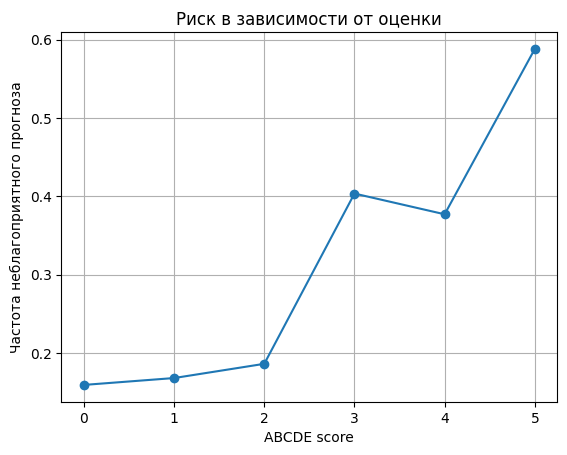

In [ ]:
grouped = (
    check.groupby('AS')['target']
    .mean()
    .reset_index()
)

plt.plot(grouped['AS'], grouped['target'], marker='o')
plt.xlabel('ABCDE score')
plt.ylabel('Частота неблагоприятного прогноза')
plt.title('Риск в зависимости от оценки')
plt.grid(True)
plt.show()

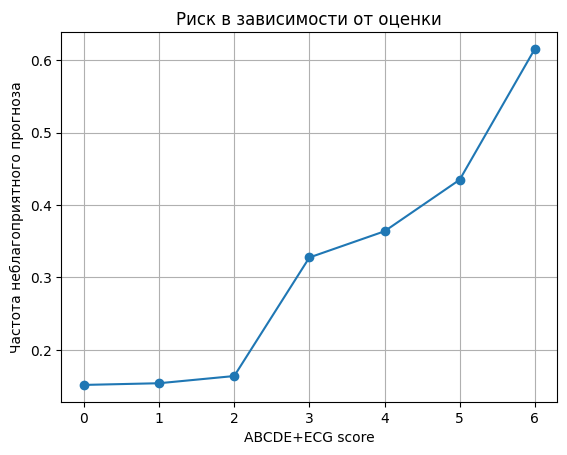

In [ ]:
grouped = (
    check.groupby('ASE')['target']
    .mean()
    .reset_index()
)

plt.plot(grouped['ASE'], grouped['target'], marker='o')
plt.xlabel('ABCDE+ECG score')
plt.ylabel('Частота неблагоприятного прогноза')
plt.title('Риск в зависимости от оценки')
plt.grid(True)
plt.show()

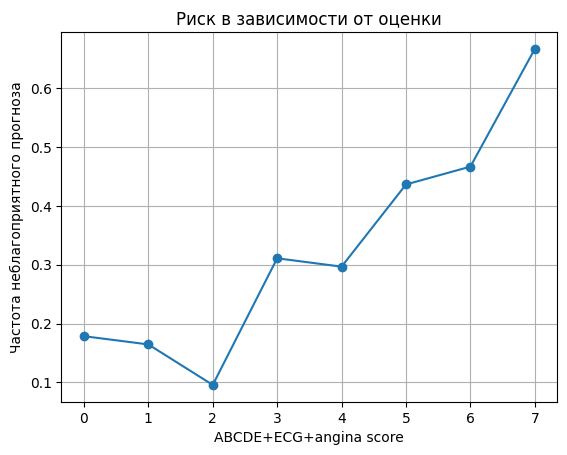

In [ ]:
grouped = (
    check.groupby('ASEA')['target']
    .mean()
    .reset_index()
)

plt.plot(grouped['ASEA'], grouped['target'], marker='o')
plt.xlabel('ABCDE+ECG+angina score')
plt.ylabel('Частота неблагоприятного прогноза')
plt.title('Риск в зависимости от оценки')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

y_true = df_for_train['target']
gls = df_for_train['GLS stress-']

fpr, tpr, thresholds = roc_curve(y_true, gls)

youden_index = tpr - fpr

best_idx = np.argmax(youden_index)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Sensitivity:", tpr[best_idx])
print("Specificity:", 1 - fpr[best_idx])

Best threshold: 6.9
Sensitivity: 1.0
Specificity: 0.0027100271002710175


In [ ]:
df_for_train.groupby('target')['GLS stress-'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0.0,369.0,18.186811,3.200460,4.6,16.4,18.2,20.366667,28.0
1.0,133.0,16.719549,2.816725,6.9,14.8,17.3,18.466667,23.6


In [ ]:
df['GLS_bin'] = pd.qcut(df['GLS stress-'], q=10)

df.groupby('GLS_bin')['target'].mean()

C:\Users\Nikita Yevdokimov\AppData\Local\Temp\ipykernel_24540\1719345262.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('GLS_bin')['target'].mean()


GLS_bin
(4.598999999999999, 13.8]    0.407407
(13.8, 15.7]                 0.352941
(15.7, 16.6]                 0.226415
(16.6, 17.34]                0.326923
(17.34, 17.9]                0.400000
(17.9, 18.44]                0.326531
(18.44, 19.22]               0.294118
(19.22, 20.3]                0.214286
(20.3, 21.4]                 0.058824
(21.4, 28.0]                 0.080000
Name: target, dtype: float64

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='target', ylabel='GLS stress-'>

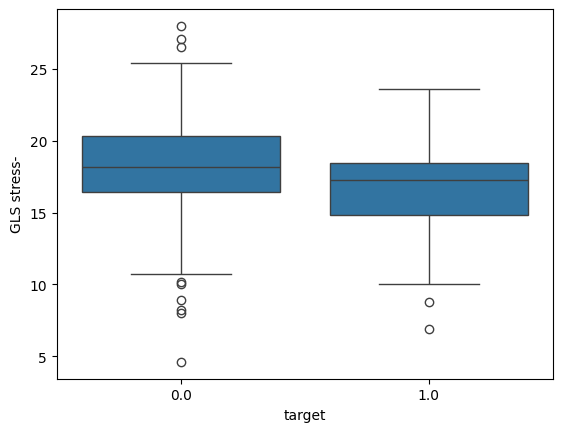

In [ ]:
sns.boxplot(
    x='target',
    y='GLS stress-',
    data=df_for_train
)

In [ ]:
bins = [5, 8, 15, 19, 28]

labels = [
    '4-11',
    '11-15',
    '15-18',
    '>18'
]

df['GLS_group'] = pd.cut(
    df['GLS stress-'],
    bins=bins,
    labels=labels
)

df.groupby('GLS_group')['target'].mean()

C:\Users\Nikita Yevdokimov\AppData\Local\Temp\ipykernel_24540\713920566.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('GLS_group')['target'].mean()


GLS_group
4-11     0.500000
11-15    0.423529
15-18    0.293878
>18      0.142012
Name: target, dtype: float64

In [ ]:
df['GLS_stress_high_risk'] = (
    df['GLS stress-'] < 20
).astype(int)

df.groupby('GLS_stress_high_risk')['target'].mean()

GLS_stress_high_risk
0    0.067227
1    0.326371
Name: target, dtype: float64